In [1]:
import numpy as np
import scipy.io
D = scipy.io.loadmat('allFaces.mat')
X = D['faces'] # 32256 x 2410, each column represents an image
y = np.ndarray.flatten(D['nfaces'])
m = int(D['m']) # 168
n = int(D['n']) # 192
n_persons = int(D['person']) # 38

C:\Users\jameslin\AppData\Local\Temp\ipykernel_15084\1138111387.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m = int(D['m']) # 168
C:\Users\jameslin\AppData\Local\Temp\ipykernel_15084\1138111387.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  n = int(D['n']) # 192
C:\Users\jameslin\AppData\Local\Temp\ipykernel_15084\1138111387.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  n_persons = int(D['person']) # 38


In [2]:
import matplotlib.pyplot as plt
def show_montage(X, n, m, h, w):
    # X: 影 像 資 料 矩 陣 ， 每 行 代 表 一 張 影 像
    # n, m: 每 張 影 像 的 大 小 n x m
    # h, w : 建 立 一 個 蒙 太 奇 圖 陣 ， 大小 figsize = (w,h)
    fig, axes = plt.subplots(h, w, figsize=(w, h))
    if X.shape[1] < w * h: # 影 像 張 數 不 到 w x h 張 ， 用 0 向量補齊
        X = np.c_[X, np.zeros((X.shape[0], w*h-X.shape[1]))]
    for i, ax in enumerate(axes.flat):
        ax.imshow(X[:,i].reshape(m, n).T, cmap='gray')
        ax.set_xticks([])
        ax.set_yticks([])
    plt.show()
#

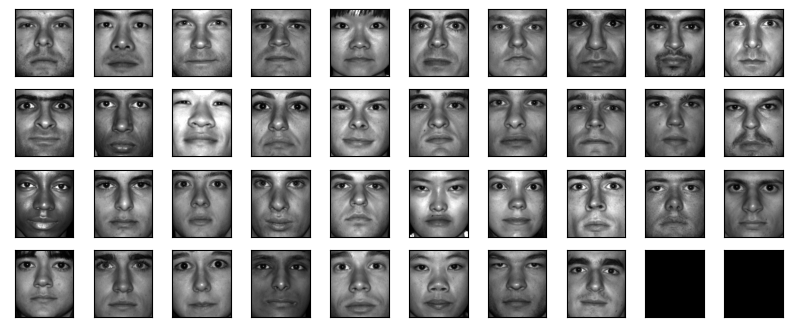

In [3]:
# 展示38人第一張影像檔
all_diff_persons = np.zeros((m*n, n_persons))
cnt = 0
for i in range(n_persons):
    all_diff_persons[:,i] = X[:,cnt]
    cnt = cnt + y[i]
show_montage(all_diff_persons, n, m, 4,10)

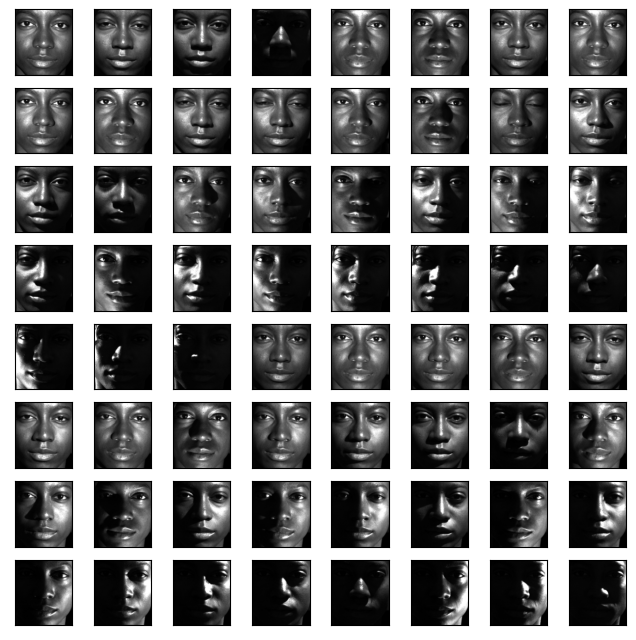

In [4]:
# 展示某個人的所有樣本影像

which_person = 20 # 0 ~ 37
start_col = y[0:which_person]. sum()
end_col = start_col + y[which_person]
show_montage(X[:, start_col:end_col], n, m, 8, 8)

In [5]:
# SVD 分解

from numpy.linalg import svd

# avgFace = X.mean(axis=1).reshape(-1, 1)
# X_avg = X - np.tile(avgFace, (1, X.shape[1]))
# 有點標準化的味道，也可以不做(所有影像作平均後扣掉，類似把亮度平均後減去)
avgFace = X.mean(axis=1)
X_avg = X - avgFace.reshape(-1,1)
# X_avg = X - avgFace[:, np.newaxis]

U, E, VT = svd(X_avg, full_matrices = False)
# U, E, VT = svd(X, full_matrices = False)

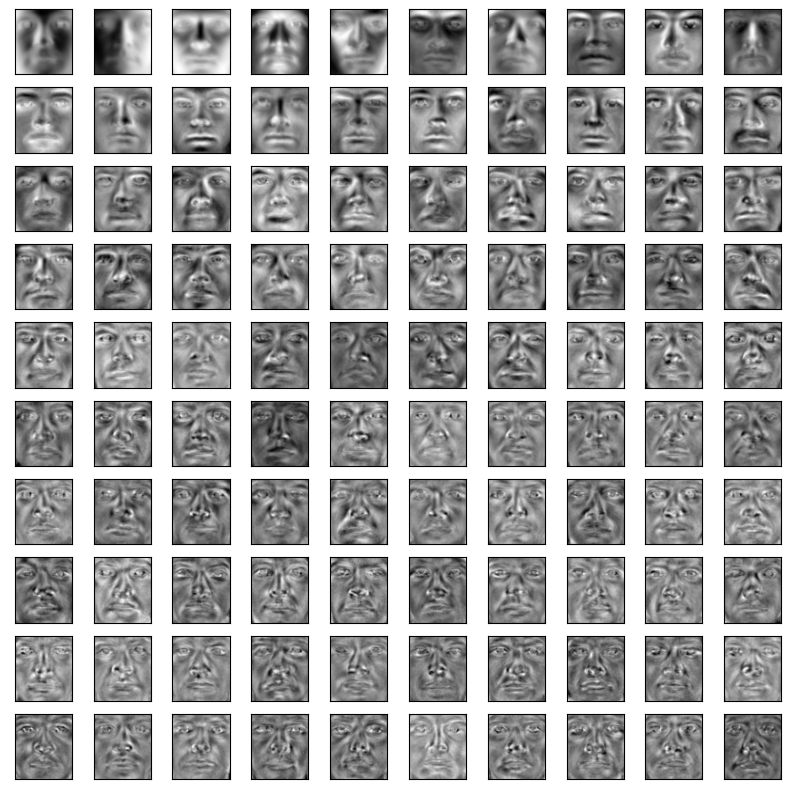

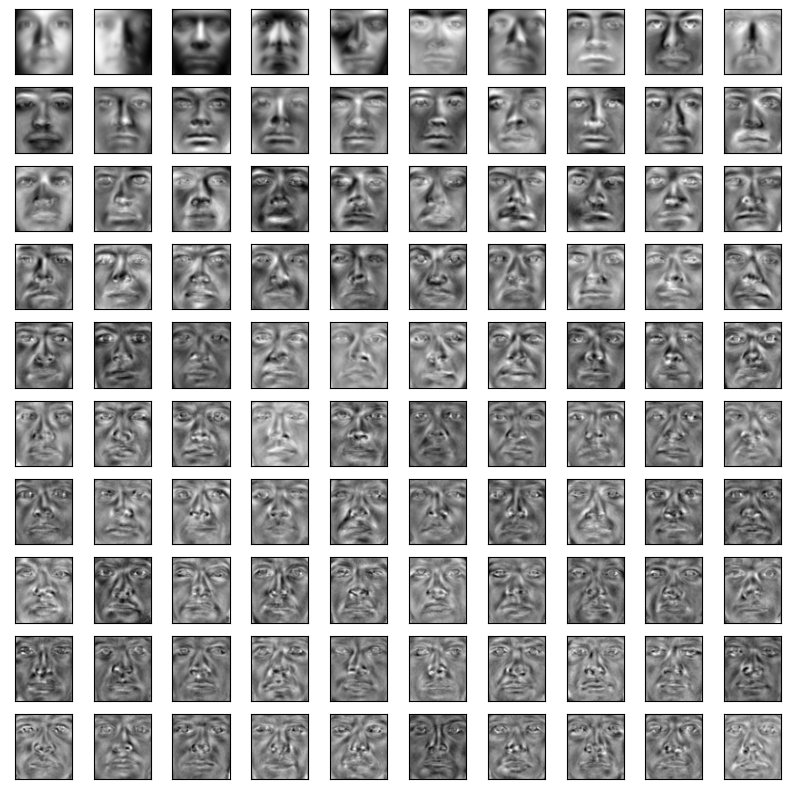

In [7]:
# 把所有人臉的特徵由大到小抓出來看
import matplotlib.pyplot as plt

# Show the first 36 bases
show_montage(U, n, m, 10, 10)
# 作對比，值是0~255
show_montage(255 - U, n, m, 10, 10)

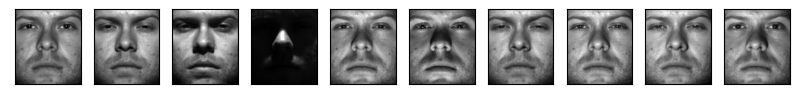

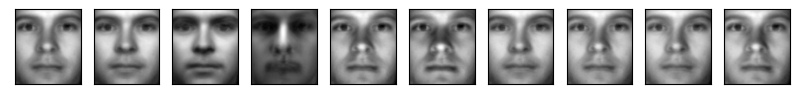

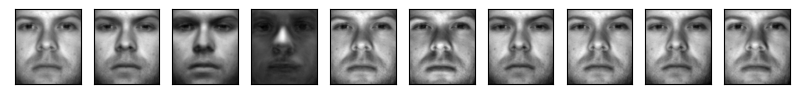

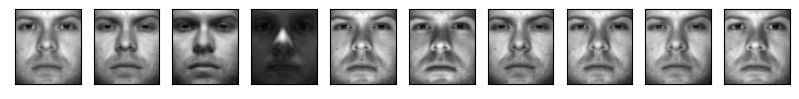

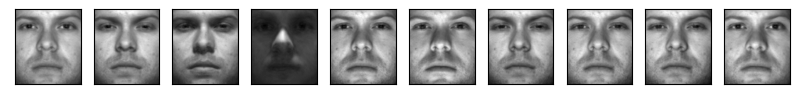

[60.2 12.   6.   3. ]


In [12]:
# 影像壓縮
h, w = 1, 10
show_montage(X, n, m, h, w)
q = np.array([20, 100, 200, 400]) #壓縮倍率
for i in q:
    Uq = U[: , :i]
    Xq = Uq @ (Uq.T @ X[:, :h*w])
    Xq = Xq + avgFace[:, np.newaxis]
    # Xq = Xq + np.tile(avgFace, (1, Xq.shape[1]))
    show_montage(Xq, n, m, h, w)

compress_ratio = (X.shape[0] *X.shape[1])/(X.shape[0] *q+q*X.shape[0])
print(np.round(compress_ratio, 1))

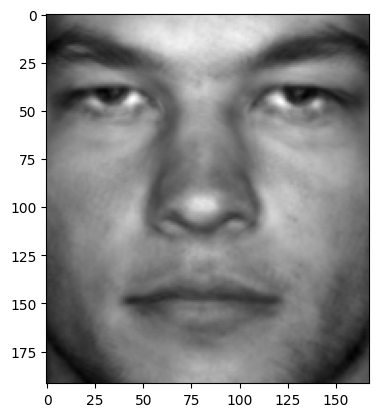

In [13]:
# 範例4:未加入主成分分析的新圖像壓縮/還原與加密/解密

# 測試 1
q = 200
x_new = X[:, np.sum(y[:36]) ]
x = U[:, 0:q] @ (U[: , 0: q] . T @ x_new) # + avgFace. reshape(1,-1)
plt. imshow(x.reshape(m, n).T, cmap='gray')
plt. show ()

In [14]:
# 拿前30人做SVD，在看看後面8人能不能直接用前面的SVD來加密解密壓縮
from numpy. linalg import svd

U_BASE = 30
U, E, VT = svd(X_avg[:, :np.sum(y[:U_BASE]) ], full_matrices = False)

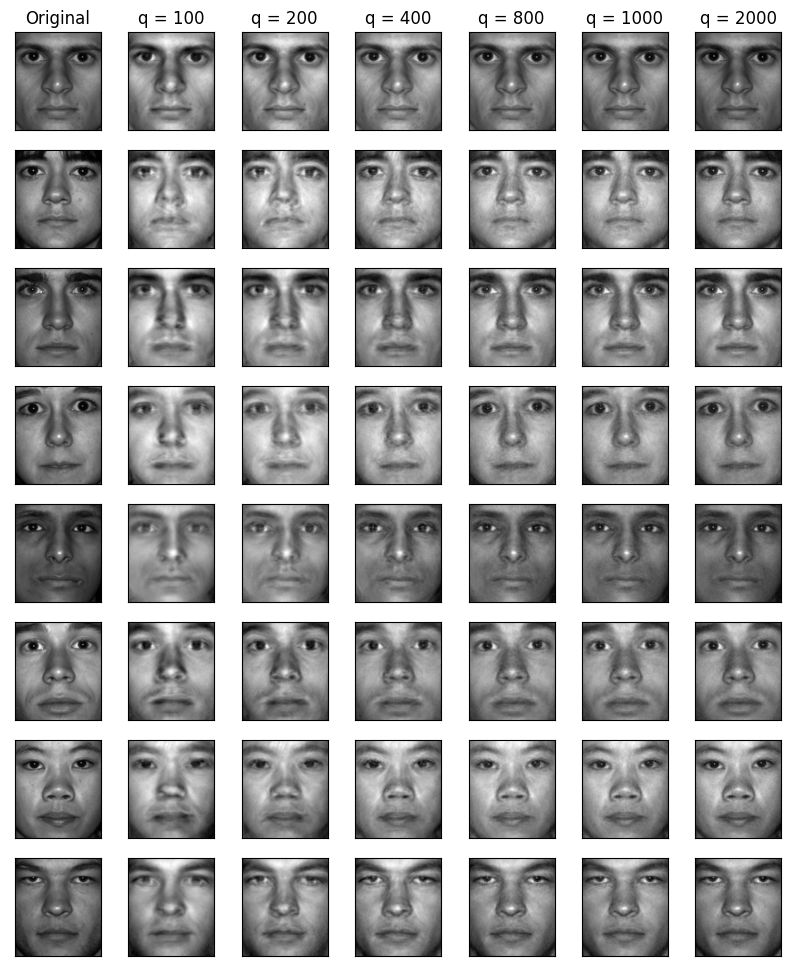

In [20]:
q = np.array([100, 200, 400, 800, 1000, 2000])
new_pic = np.arange(30,38,1) # really new pictures
# new_pic = np.arange(10,18,1) # pictures that participate in creating U
fig, ax = plt.subplots(len(new_pic), len(q)+1, figsize=(10, 12))

for i in range(len(new_pic)):
    x_new=X[:, np.sum(y[:(new_pic[i]-1)])]
    ax[i] [0]. imshow((x_new). reshape(m, n).T, cmap='gray')
    ax[i] [0] . set_xticks([])
    ax[i] [0] . set_yticks([])
    ax[0] [0] . set_title('Original')

    for j, r in enumerate(q):
        x = U[:, 0: q[j]] @ (U[:, 0: q[j]] . T @ x_new)
        ax[i][j+1]. imshow((x). reshape(m, n).T, cmap='gray')
        ax[i] [j+1]. set_xticks([])
        ax[i][j+1] . set_yticks([])
        if i == 0:
            ax[i][j+1] . set_title('q = {}'. format(q[j]))

plt. show ()